In [43]:
import pennylane as qml
from pennylane import numpy as qnp
# from pennylane.optimize import AdamOptimizer
from pennylane.templates import AmplitudeEmbedding


from pathlib import Path
from torch import nn
from torch.optim import Adam
import torch
from tqdm import tqdm
from Data.Primitives.environment_classes import Drone, Radar, Context
from Data.Primitives.noise_models import AdditiveWhiteGaussianNoise
from Data.Primitives.presets import *
from Data.Generators.synthetic_dataset_generator import DatasetMetadata, DataRequest

from MachineLearning.Processing.file_loader import SyntheticDataFileLoader
from MachineLearning.Processing.frequency_domain_parser import FrequencyDomainDataParser
from MachineLearning.Processing.time_domain_parser import TimeDomainDataParser
from MachineLearning.Torch_datasets.synthetic_time_dataset import SyntheticTimeDomainRadarDataset
from MachineLearning.Torch_datasets.synthetic_frequency_dataset import SyntheticFrequencyDomainRadarDataset
from MachineLearning.Models.experiment_pure.classical_neural_network import ClassicalNeuralNetwork
from MachineLearning.Models.experiment_pure.quantum_neural_network import QuantumNeuralNetwork
from MachineLearning.Processing.data_visualizer import DataVisualizer
from MachineLearning.Trainers.statistical_trainer import TrainerForModelStatistics
from MachineLearning.Trainers.hyperparameter_trainer import TrainerForHyperparameterSearch
from MachineLearning.Trainers.abstract_trainer import AbstractTrainer

from torch.utils.data import DataLoader

In [68]:
class QuantumNeuralNetwork(nn.Module):
    def __init__(self, config):
        super(QuantumNeuralNetwork, self).__init__()
        self.encodings = {
            "angle" : self.angle_encoding,
            "amplitude": self.amplitude_embedding
        }
        self.ansatzes = {
            "basic" : self.basic_ansatz,
        }

        self.init_kwargs = {
            "n_qubits": config['n_qubits'],
            "layers": config['layers'],         #TODO this might be broken
            "encoding": config["encoding"],
            "ansatz": config["ansatz"],
            "simulator": config["simulator"],
        }

        self.model_name = self.__class__.__name__
        self.dev = qml.device(self.init_kwargs["simulator"], wires=config["n_qubits"])

        self.qnode = qml.QNode(self.basic_classifier, self.dev, interface='torch')

    def angle_encoding(self, x):
        n_qubits = len(x)
        qml.AngleEmbedding(features=x, wires=range(n_qubits), rotation='X')
        for i in range(n_qubits):
            if i+1< n_qubits:
                qml.CNOT(wires=[i, i+1])

    def amplitude_embedding(self, x):
        n_qubits = len(x)
        qml.AmplitudeEmbedding(features=x, wires=range(n_qubits), pad_with=0.)

    def basic_ansatz(self, params):
        n_layers, n_qubits = params.shape[0], params.shape[1]
        for i in range(n_layers):
            for j in range(n_qubits):
                qml.Rot(params[i,j,0], params[i,j,1], params[i,j,2], wires=j)
            for j in range(n_qubits-1):
                qml.CNOT(wires=[j,j+1])

    def basic_classifier(self, params, x):
        self.encodings[self.init_kwargs['encoding']](x)
        # self.amplitude_embedding(x)
        for i in range(self.init_kwargs['layers']):
            self.ansatzes[self.init_kwargs['ansatz']](params)
        return qml.expval(qml.PauliZ(0))


    def forward(self, x):
        pass

In [64]:
MODEL_REGISTRY = {
    "QuantumNeuralNetwork": QuantumNeuralNetwork,
}


class QuantumTrainer(AbstractTrainer):
    def __init__(self, training_path, validating_path, testing_path, criterion):
        super().__init__(training_path, validating_path, testing_path, criterion)

    # def return_config_from_ray_results(self, best_result, map_location="cpu"):
    #     checkpoint = best_result.checkpoint
    #     with checkpoint.as_directory() as checkpoint_dir:
    #         checkpoint_path = Path(checkpoint_dir) / "checkpoint.pt"
    #         checkpoint_data = torch.load(checkpoint_path, map_location=map_location)
    #
    #     model_class_name = checkpoint_data["model_class_name"]
    #     model_init_kwargs = checkpoint_data["model_init_kwargs"]
    #     net_state_dict = checkpoint_data["net_state_dict"]
    #
    #     # model_class = MODEL_REGISTRY[model_class_name]
    #     # model = model_class(**model_init_kwargs)
    #     # model.load_state_dict(net_state_dict)
    #     # model.eval()
    #     return model_class_name, model_init_kwargs, net_state_dict


    def train_model(self, model_class, config, number_of_epochs=50):

        device = config["device"]

        net = model_class(      # needs to be fixed
            layers=config["layers"],
            neurons_per_layer=config["neurons_per_layer"]
        ).to(device)

        optimizer = Adam(net.parameters(), lr=config["lr"])
        trainloader = DataLoader(self.trainset, batch_size=int(config["batch_size"]), shuffle=True, num_workers=2) # Do poprawienia
        valloader = DataLoader(self.valset, batch_size=int(config["batch_size"]), shuffle=False, num_workers=2)

        data_dict = {
            "accuracy": [],
            "validation_loss": []
        }

        for epoch in tqdm(range(number_of_epochs), desc='Epochs'):
            net.train()

            for inputs, labels in trainloader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = net(inputs)
                loss = self.criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            net.eval()
            val_loss = 0.0
            val_steps = 0
            total = 0
            correct = 0

            with torch.no_grad():
                for inputs, labels in valloader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = net(inputs)
                    loss = self.criterion(outputs, labels)
                    val_loss += loss.item()
                    val_steps += 1
                    predicted = outputs.argmax(dim=1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()


            data_dict["validation_loss"].append(val_loss / val_steps)
            data_dict["accuracy"].append(100 * correct / total)


        return data_dict

    def test_model(self, model):
        pass

In [65]:
PROJECT_ROOT = Path().cwd().parent.parent
training_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "validating_dataset.pkl"
testing_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "testing_dataset.pkl"

trainer = QuantumTrainer(training_path, validating_path, testing_path, criterion=nn.MSELoss())

C:\Users\adria\AppData\Local\Temp\ipykernel_15000\203761637.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


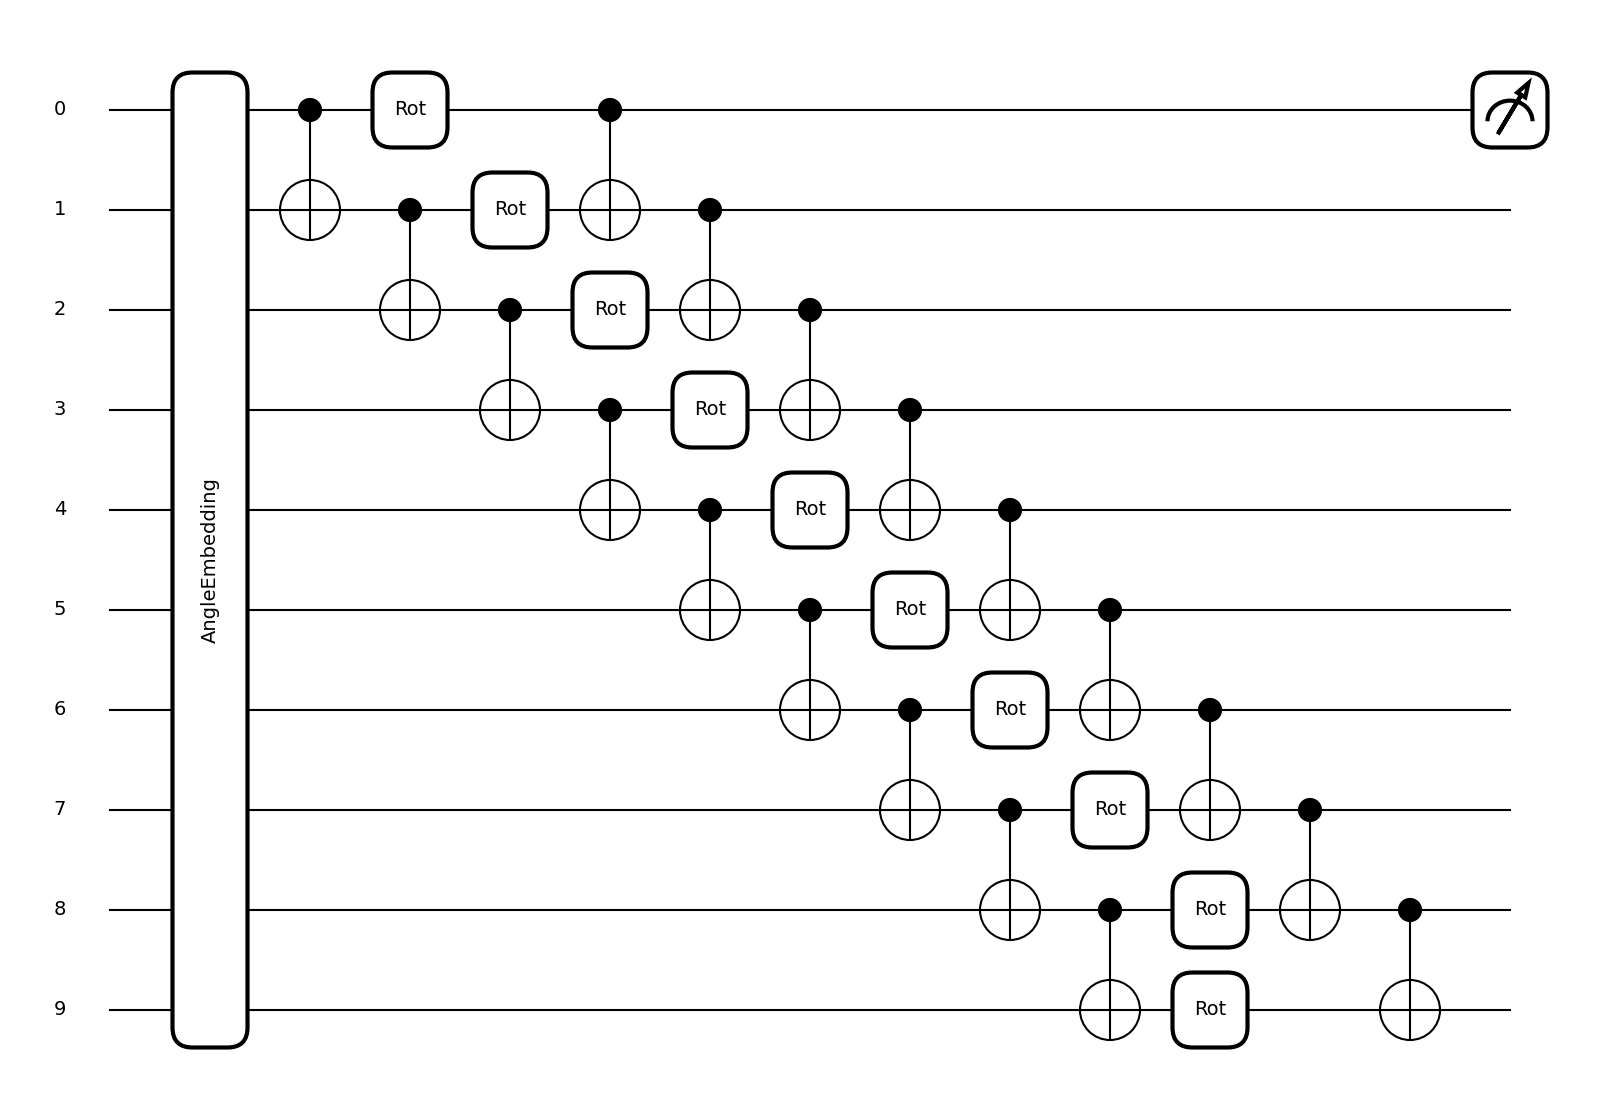

In [72]:
config = {
    "n_qubits"  : 10,
    "layers"    : 1,
    "encoding"  : "angle",
    "ansatz"    : "basic",
    "simulator" : 'lightning.qubit',
}

qnn = QuantumNeuralNetwork(config)

params = torch.randn((1, 10, 3), requires_grad=True)
x = torch.randn(10)

y = qnn.qnode(params=params, x=x)
fig, ax = qml.draw_mpl(qnn.qnode)(params=params, x=x)
fig.show()